In [31]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from WFPreprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known= preprocess_data(filtered_time, data_orig)
#X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known, X, y = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 3)
Next slips shape (4897, 8)
orig shape (5150, 8)


In [33]:
# Seperating into two subsets, one with 12 hour slips and one with 24 hour slips 

filtered_time["interval"] = np.where(
    abs(filtered_time["time_to_next_ev_hr"]-12) <= abs(filtered_time["time_to_next_ev_hr"]-24), 
    "12h", "24h") 
t_12 = filtered_time[filtered_time["interval"]=="12h"]
t_24 = filtered_time[filtered_time["interval"]=="24h"]

print(t_12.head())
print(t_24.head())

   Unnamed: 0          ev_time_utc  time_to_next_ev_hr interval
0           0  2008-01-25 01:50:00           17.354167      12h
2           2  2008-01-26 16:57:15           10.758333      12h
3           3  2008-01-27 03:42:45           13.254167      12h
6           6  2008-01-29 11:03:00           10.487500      12h
7           7  2008-01-29 21:32:15           11.895833      12h
    Unnamed: 0          ev_time_utc  time_to_next_ev_hr interval
1            1  2008-01-25 19:11:15           21.766667      24h
4            4  2008-01-27 16:58:00           19.112500      24h
5            5  2008-01-28 12:04:45           22.970833      24h
22          22  2008-02-06 16:45:30           23.866667      24h
25          25  2008-02-08 17:22:45           21.929167      24h


In [34]:
'''# Create full-length masked time series
t_12_full = t_12.reindex(data_orig.index)

# Pass full-length objects into preprocessing
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = \
    preprocess_data(t_12_full, data_orig)

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(t_12_full, data_orig)

'''
t_24_full = t_24.reindex(data_orig.index)

# Pass full-length objects into preprocessing
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = \
    preprocess_data(t_24_full, data_orig)

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(t_24_full, data_orig)

0       True
1       True
2       True
3       True
4       True
        ... 
5145    True
5146    True
5147    True
5148    True
5149    True
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(5146, 4)
Next slips shape (5146, 8)
orig shape (5150, 8)
0       True
1       True
2       True
3       True
4       True
        ... 
5145    True
5146    True
5147    True
5148    True
5149    True
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(5146, 4)
Next slips shape (5146, 8)
orig shape (5150, 8)


In [35]:
# Running each subset through XGBoost 

#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-02-18 22:14:52,701] A new study created in memory with name: no-name-b4c8bc32-a6f8-443e-99c1-32a3dffbf60d
[I 2026-02-18 22:14:53,394] Trial 0 finished with value: 5830.7767397147345 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 5830.7767397147345.
[I 2026-02-18 22:14:54,004] Trial 1 finished with value: 5917.1456887122895 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 5830.7767397147345.
[I 2026-02-18 22:14:54,974] Trial 2 finished with value: 5949.33045492869 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 5830.7767397147345.
[I 2026-02-18 22:14:55,517] Trial 3 finished with value: 6149.7749766114985 and

Optimal Parameters: {'learning_rate': 0.011615865989246453, 'max_depth': 5, 'subsample': 0.8896896099223679, 'colsample_bytree': 0.8425192044349383}
XGBoost Error: 7193.986372128573
Mean XGBoost Error: 4497.130208333333


1410     85875.0
3500     85470.0
3347     70935.0
1722     91080.0
1306     84495.0
          ...   
4454     75000.0
2659     89490.0
4159     89925.0
5025    100950.0
752      89445.0
Name: time_to_next_ev_hr, Length: 366, dtype: float64
[85063.516 88223.34  88369.01  85839.72  87133.16  88298.055 90733.055
 74465.836 84274.83  88113.375 88854.14  87312.24  86695.41  86091.62
 71260.47  88460.06  85873.26  82437.87  86919.16  86625.98  80506.96
 73142.96  94832.1   78087.56  84995.99  69729.375 87749.73  84173.875
 83774.84  83849.54  88063.305 82682.516 73444.086 72960.83  89443.66
 75647.01  87000.79  77849.984 84665.46  87579.88  79106.31  82428.07
 72260.516 79955.125 82597.016 75048.32  72305.49  86464.08  80626.555
 87876.664 76382.04  86263.49  80417.89  87261.31  75464.95  86055.72
 89072.19  79536.96  89392.15  85992.27  86977.73  85727.    97129.15
 83034.695 85239.055 88069.79  88059.48  84421.18  83027.58  83378.164
 88026.39  83738.65  89566.78  86336.086 87125.46  8603

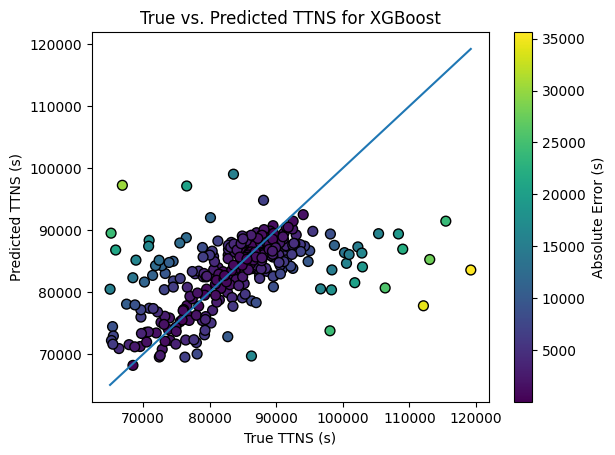

In [36]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
plt.show()

In [37]:
# Compute absolute errors
print("Length of Subset", len(XG_pred_secs))
diff = np.abs(XG_pred_secs - y_test_secs)

# Threshold for outliers
threshold = 20000  # adjust as needed

# Get indices of outliers in the test set
X_outliers = np.where(diff > threshold)[0]

print("Number of Outliers", len(X_outliers))
print(f"Outliers (error > {threshold}):")

# Print details for only outliers
for idx in X_outliers:
    true = y_test_secs.iloc[idx]   # pandas Series: use iloc
    pred = XG_pred_secs[idx]       # numpy array: use normal indexing
    print(f"Index position {idx}: True={true}, Predicted={pred}")

Length of Subset 366
Number of Outliers 12
Outliers (error > 20000):
Index position 62: True=76574.99999999999, Predicted=97129.1484375
Index position 113: True=112110.0, Predicted=77824.6640625
Index position 117: True=66915.0, Predicted=97242.78125
Index position 139: True=98085.0, Predicted=73793.0
Index position 146: True=109005.0, Predicted=86952.4375
Index position 162: True=119220.0, Predicted=83590.78125
Index position 202: True=65910.0, Predicted=86811.6015625
Index position 205: True=65220.0, Predicted=89528.0546875
Index position 212: True=113055.0, Predicted=85280.7734375
Index position 306: True=115470.00000000001, Predicted=91462.234375
Index position 309: True=106364.99999999999, Predicted=80697.5078125
Index position 339: True=101805.0, Predicted=81542.2421875


 94%|=================== | 345/366 [00:13<00:00]       

XG Boost Drivers: tide_height    2299.496920
time_since     1260.020273
tide_deriv     1092.407253
form_fac        982.362654
slip_size       713.706750
high_t_evt       84.001240
dtype: float64


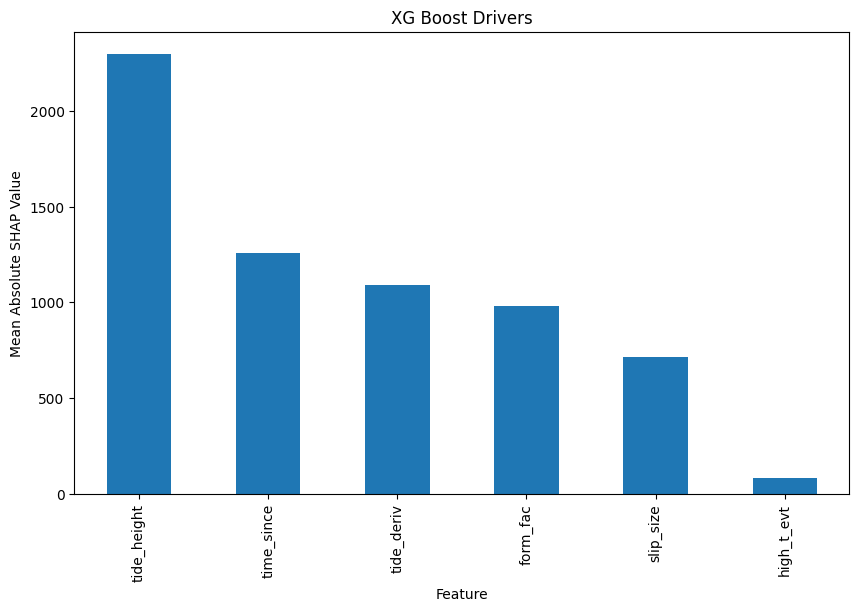

In [38]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()

In [39]:
#Averaging the value of each feature in the subset so future events can be placed in a subset accordingly 

t_24_features = data_orig.loc[t_24.index]
t_12_features = data_orig.loc[t_12.index]

feature_cols = [
    "tide_deriv",
    "form_fac",
    "time_since",
    "slip_size",
    "high_t_evt",
    "tide_height"
]

mean_24 = t_24_features[feature_cols].mean()
mean_12 = t_12_features[feature_cols].mean()

print(mean_24)
print(mean_12)




tide_deriv       -0.095149
form_fac          3.870052
time_since     1186.889497
slip_size         0.165857
high_t_evt        0.704595
tide_height      32.916218
dtype: float64
tide_deriv       -0.157254
form_fac          2.879485
time_since     1219.971018
slip_size        -0.410569
high_t_evt        0.537929
tide_height       4.149374
dtype: float64


In [ ]:
#Should be in another notebook

In [ ]:
# ***I don't think data orig is the correct thing to be referencing. This needs looked at/thought about further 

# Checking which subset (12 or 24 each event should fall into):

hr_12weights = np.array([-0.095149, 3.870052, 1186.889497, 0.165857, 0.704595, 32.916218])
hr_24weights = np.array([-0.157254, 2.879485, 1219.971018, -0.410569, 0.537929, 4.149374])

results = []

for idx, row in data_orig.iterrows():
    zeros = 0
    ones = 0
    
    # Track which one feature 3 is closer to
    TS_dist12 = abs(row["time_since"] - hr_12weights[2])
    TS_dist24 = abs(row["time_since"] - hr_24weights[2])
    
    # Loop through features
    for i, col in enumerate(feature_cols):
        dist12 = abs(row[col] - hr_12weights[i])
        dist24 = abs(row[col] - hr_24weights[i])
        
        if dist12 <= dist24:
            zeros += 1
        else:
            ones += 1
    
    # Majority decision
    if ones > zeros:
        results.append(1)
    elif zeros > ones:
        results.append(0)
    else:
        # Tie → use feature 3 distance as tiebreaker
        results.append(0 if TS_dist12 <= TS_dist24 else 1)

data_orig["final_result"] = results
print(results)

total_ones = (data_orig['majority_vote'] == 1).sum()
total_zeros = (data_orig['majority_vote'] == 0).sum()

print("Total majority 0s:", total_zeros)
print("Total majority 1s:", total_ones)

[1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 